# Sap Flow and Transpiration — Recent (2026) Data

Sap flow is the movement of water through the xylem of a tree. Measured in the
water-conducting sapwood, it is a direct proxy for **transpiration** — the water
a tree draws up and releases through its leaves. On a clear day, transpiration is
driven largely by atmospheric demand, quantified by the **vapor pressure deficit
(VPD)**: the gap between how much water vapor the air *could* hold and how much it
*does* hold.

This notebook queries **recent 2026 data** live from Sage Continuum for the six
sap flow meters on the NEIU campus, computes VPD from the co-located Vaisala WXT
weather station, and displays:

1. a **time series** of sap flow with VPD overlaid, and
2. a **diel heatmap** (day-of-year × hour-of-day) for each tree, which reveals
   the daily transpiration rhythm sweeping across the season.

It is a companion to `sage_data_access.ipynb` and reuses the same `sage_utils`
query functions and `crocus_sites` metadata. For historical (pre-2026) data,
which was sampled at higher and mixed cadences, a separate notebook built on the
resampled archive is planned.

<table>
<tr><td>
<img src="https://ictinternational.com/wp-content/uploads/2023/03/HFD-Needles-1024x707.png" height="180" />
</td><td>
<img src="https://ictinternational.com/wp-content/uploads/2023/05/SFM1-installed-on-Rainforest-Species-scaled-jpg.webp" height="180"/>
</td></tr>
</table>

The NEIU sap flow meters are ICT International **SFM1** sensors. Each has three
needles: a central heater and two thermistors that measure a heat pulse at two
sapwood depths (7.5 mm = *outer*, 22.5 mm = *inner* from the needle tip).

- ICT International: https://ictinternational.com/
- SFM1 manual: https://labcontrol.com.br/wp-content/uploads/2018/03/SFM1-Manual-v5.pdf
- NEIU node on the Sage portal: https://portal.sagecontinuum.org/nodes/W08D


## Theory in brief

The SFM1 uses the **Heat Ratio Method** (HRM) of Burgess et al. (2001). Only the
three working equations are given here; the full heat-transport derivation is in
Marshall (1958) and Burgess et al. (2001), and is summarized in the appendix.

**1. Heat pulse velocity.** From the ratio of the temperature rises at the two
thermistors equidistant ($x$) from the heater,

$$
V_h = \frac{k}{x}\,\ln\!\left(\frac{\Delta T_1}{\Delta T_2}\right)\cdot 3600
$$

where $k \approx 2.5\times10^{-3}\ \mathrm{cm^2\,s^{-1}}$ is the thermal
diffusivity of green wood and $x = 0.6$ cm is the probe spacing.

**2. Wound correction.** Drilling wounds the wood and biases $V_h$; the correction
is a polynomial (coefficients from the SFM1 manual, after Swanson & Whitfield 1981):

$$
V_c = b\,V_h + c\,V_h^2 + d\,V_h^3
$$

**3. Sap velocity → flow.** Converting corrected heat-pulse velocity to sap
velocity accounts for the thermal properties and water content of the wood
(Marshall 1958):

$$
V_s = \frac{V_c\,\rho_b\,(c_w + m_c c_s)}{\rho_s c_s}
$$

Multiplying $V_s$ by the tree's **sapwood area** gives volumetric sap flow (kg h⁻¹).
Sapwood area requires per-tree circumference / core measurements, which are **not
yet available** — so this notebook plots the *uncorrected heat-pulse velocity*
(`inner` and `outer`, cm h⁻¹) that the sensor reports directly. The kg h⁻¹
conversion is stubbed at the end of the notebook for when those measurements arrive.

**VPD.** The atmospheric driver. Saturated vapor pressure $P_s(T)$ is computed from
the WXT air temperature via the Arden Buck equation, and

$$
\mathrm{VPD} = P_s(T)\left(1 - \frac{\mathrm{RH}}{100}\right).
$$


In [1]:
# Run this cell first in Google Colab.
# It is harmless in a normal local Jupyter session.

import os
import sys
from pathlib import Path

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ

if IN_COLAB:
    %cd /content
    !git clone -q https://github.com/gregorywanderson/crocus.git
    %cd /content/crocus
    !pip install -q -r requirements.txt

# Make sure Python can find local modules such as sage_utils.py
# and crocus_sites.py.
if IN_COLAB:
    sys.path.insert(0, "/content/crocus")
else:
    sys.path.insert(0, str(Path.cwd()))

In [2]:
# Standard library
import datetime as dt
import importlib
import math
import ssl

# Third party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sage_data_client

# Local
import crocus_sites
import sage_utils

importlib.reload(crocus_sites)
importlib.reload(sage_utils)

# Sites carrying sap flow meters (has_sapflow=True): BIG, CSU, NEIU, NU, UIC
from crocus_sites import ALL_SITES, BIG, CSU, NEIU, NU, UIC
from sage_utils import query_wxt, query_sapflow, last_n_hours

ssl._create_default_https_context = ssl._create_unverified_context

## Site and date window

Set `SITE` to any CROCUS site that carries sap flow meters: **NEIU, NU, CSU, UIC,
or BIG**. By default we look at a recent multi-week window of 2026 data. Sap flow
arrives over LoRaWAN and can have gaps; the queries return 5-minute means for
consistency.


In [3]:
# Sites with sap flow meters: BIG, CSU, NEIU, NU, UIC.
# Change SITE to any of these to run the notebook for a different location.
SITE = NEIU   # <- pick your site: NEIU, NU, CSU, UIC, or BIG

# Recent window: the last ~10 weeks. Adjust START/END to taste.
END   = dt.date.today().isoformat()
START = (dt.date.today() - dt.timedelta(weeks=10)).isoformat()

if not SITE.has_sapflow:
    print(f"{SITE.abbr} ({SITE.full_name}) has no sap flow meters.")
    print("Sites with sap flow:",
          ", ".join(s.abbr for s in ALL_SITES if s.has_sapflow))
else:
    print(f"Site : {SITE.full_name} ({SITE.vsn})")
    print(f"Range: {START} to {END}")
    print(f"Trees: {len(SITE.sapflow)} sap flow meters")
    for serial, species in SITE.sapflow.items():
        print(f"   {serial}  {species}")

Site : Northeastern Illinois University (W08D)
Range: 2026-04-23 to 2026-07-02
Trees: 6 sap flow meters
   SX61NA0C  white_oak_1
   SX61NA0X  white_oak_2
   SX61NA0V  american_elm_1
   SX61NA01  sugar_maple_1
   SX61NA0J  sugar_maple_2
   SX61NA0N  sugar_maple_3


## Vapor pressure deficit

`vp_sat` returns saturated vapor pressure (hPa) for a temperature in °C using the
Arden Buck equation. VPD is then $P_s(T)\,(1 - \mathrm{RH}/100)$. The WXT reports
temperature already in °C and relative humidity in %, so no unit conversion is
needed (unlike the old Ambient Weather feed, which was in °F).


In [4]:
def vp_sat(T):
    """Saturated vapor pressure (hPa) for temperature T (°C), Arden Buck (1981, 1996)."""
    if T > 0:
        Pc, A, B, C = 6.1121, 18.678, 234.5, 257.14
    else:
        Pc, A, B, C = 6.1115, 23.036, 333.7, 279.82
    return Pc * math.exp((A - T / B) * T / (C + T))

vp_sat_vectorized = np.vectorize(vp_sat)


def add_vpd(wxt):
    """Given a wide WXT frame with 'temp' (°C) and 'humidity' (%), add a 'VPD' column (hPa)."""
    wxt = wxt.copy()
    wxt["Ps"]  = vp_sat_vectorized(wxt["temp"].to_numpy(dtype=float))
    wxt["VPD"] = wxt["Ps"] * (1.0 - wxt["humidity"] / 100.0)
    return wxt

## Query the WXT and compute VPD


In [5]:
wxt = query_wxt(SITE, START, END)

if wxt.empty:
    print(f"No WXT data returned for {SITE.abbr} in {START}..{END}.")
else:
    wxt = add_vpd(wxt)
    print(f"WXT rows: {len(wxt)}   VPD range: "
          f"{wxt['VPD'].min():.1f}–{wxt['VPD'].max():.1f} hPa")
    wxt[["temp", "humidity", "VPD"]].head()

WXT rows: 14695   VPD range: 0.0–30.5 hPa


/home/anderson/miniforge3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in vp_sat (vectorized)
  outputs = ufunc(*args, out=...)


## Query the sap flow meters

`query_sapflow` returns a dict keyed by serial number; each value is a wide frame
with `inner` and `outer` (uncorrected heat-pulse velocity, cm h⁻¹), a UTC index,
and a `battery_voltage` column. We attach the species label from `crocus_sites`
for nicer plot legends.


In [6]:
sapflow = query_sapflow(SITE, START, END)

if not sapflow:
    print(f"No sap flow data returned for {SITE.abbr}.")
else:
    print(f"Trees with data ({len(sapflow)}):")
    for serial, df in sapflow.items():
        species = SITE.sapflow.get(serial, serial)
        n_out = df['outer'].notna().sum()
        n_in  = df['inner'].notna().sum()
        print(f"   {serial}  {species:<16}  {len(df):5d} rows  "
              f"(outer {n_out}, inner {n_in} valid)")

Trees with data (4):
   white_oak_2  white_oak_2        3428 rows  (outer 3422, inner 3424 valid)
   sugar_maple_1  sugar_maple_1      3527 rows  (outer 3521, inner 3523 valid)
   sugar_maple_2  sugar_maple_2      5222 rows  (outer 5218, inner 5215 valid)
   sugar_maple_3  sugar_maple_3      5220 rows  (outer 5215, inner 5215 valid)


## Diagnostic: which trees reported, which look suspect

NEIU has six meters. Not all report in every window, and a probe seated in
non-conducting wood or with a bad zero can read all-NaN, all-zero, or persistently
negative. This cell flags those so they aren't mistaken for biology.

**Note on negative values.** Brief negative sap flow is *real*: at night, xylem can
refill and flow can briefly reverse, which is exactly what the Heat Ratio Method was
designed to detect (Burgess et al. 2001). Sustained *daytime* negatives, or a sensor
that is negative almost everywhere, indicate a calibration/seating problem instead.


In [7]:
# query_sapflow returns a dict keyed by SPECIES LABEL; each DataFrame also
# carries a 'serial' column, so we read the serial straight from the frame.
configured_species = set(SITE.sapflow.values())   # all trees at this site
reported_species   = set(sapflow)                  # trees that returned data

print(f"{SITE.abbr}: {len(configured_species)} meters configured, "
      f"{len(reported_species)} returned data\n")

# Missing trees (configured but no data in this window)
serial_of = {sp: serial for serial, sp in SITE.sapflow.items()}
for species in configured_species - reported_species:
    print(f"  MISSING   {serial_of[species]}  {species}")

# Reported trees, with suspect-sensor flags
for species, df in sapflow.items():
    serial = df["serial"].iloc[0] if "serial" in df.columns else "?"
    valid = df["outer"].dropna()
    flags = []
    if valid.empty:
        flags.append("all-NaN")
    else:
        frac_neg = (valid < 0).mean()
        if frac_neg > 0.5:
            flags.append(f"{frac_neg:.0%} negative (suspect)")
        if valid.abs().max() < 1.0:
            flags.append("near-zero (suspect)")
    tag = "  ".join(flags) if flags else "ok"
    print(f"  reported  {serial}  {species:<16}  "
          f"n={len(valid):5d}  median={valid.median():5.1f}  {tag}")

NEIU: 6 meters configured, 4 returned data

  MISSING   SX61NA0C  white_oak_1
  MISSING   SX61NA0V  american_elm_1
  reported  SX61NA0X  white_oak_2       n= 3422  median=  4.9  ok
  reported  SX61NA01  sugar_maple_1     n= 3521  median=  0.1  ok
  reported  SX61NA0J  sugar_maple_2     n= 5218  median=  5.3  ok
  reported  SX61NA0N  sugar_maple_3     n= 5215  median=  2.4  ok


## Time series: sap flow with VPD

Two stacked panels sharing a time axis. **Top:** inner (dashed) and outer (solid)
heat-pulse velocity for every tree. **Bottom:** VPD from the co-located WXT. On
fair-weather days the trees' sap flow should track the VPD envelope — rising
through the morning, peaking near midday, falling toward evening.

**Radiation hook.** The WXT does not measure radiation. The MFR node *may* publish
a shortwave / heat-flux channel, but `query_mfr` does not currently expose it. The
figure below leaves a clearly marked place to add radiation as a third panel once
its column name is confirmed.


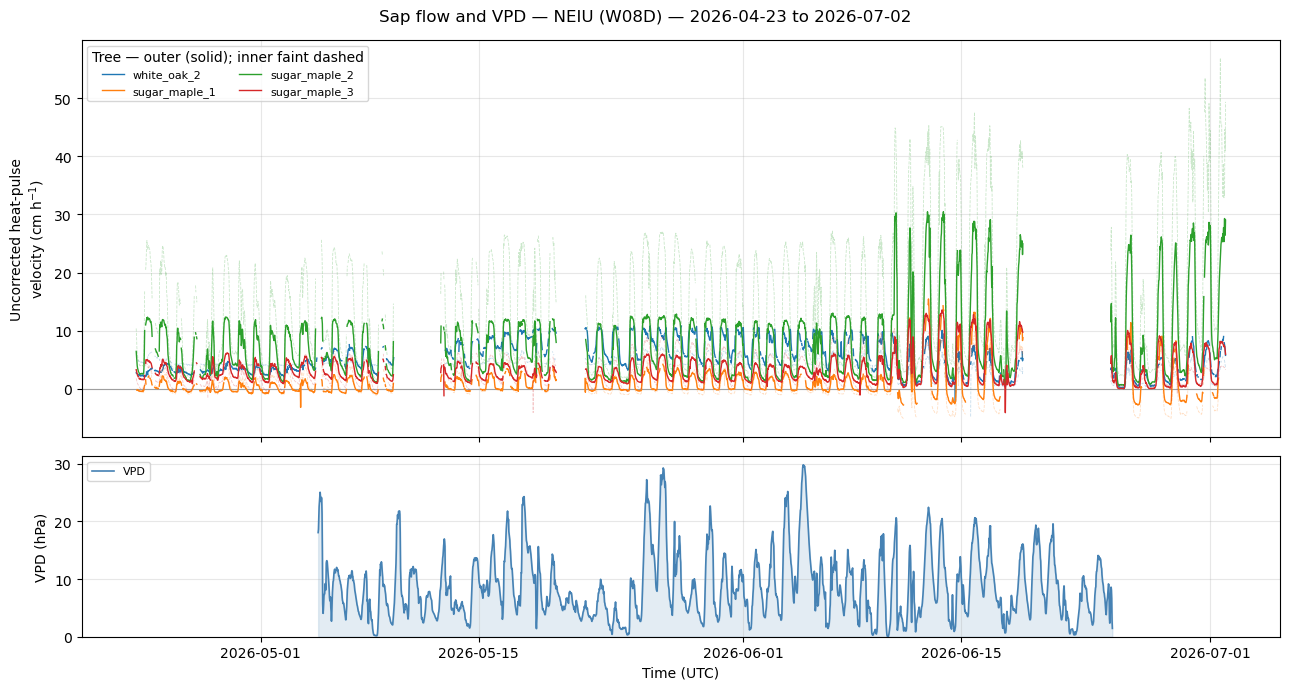

In [8]:
# Resample each tree onto a regular grid so gaps become NaN
# (matplotlib then breaks the line instead of drawing false diagonals).
GRID_MIN_TS = 30   # minutes; matches the diel heatmap grid

def on_grid(series, grid_min=GRID_MIN_TS):
    s = series.copy()
    if s.index.tz is None:
        s.index = s.index.tz_localize("UTC")
    return s.resample(f"{grid_min}min").mean()

if sapflow and not wxt.empty:
    fig, (ax_sap, ax_vpd) = plt.subplots(
        2, 1, figsize=(13, 7), sharex=True,
        gridspec_kw={"height_ratios": [2.2, 1]}
    )

    # --- Top: sap flow. Solid outer (primary), faint dashed inner. ---
    cmap = plt.get_cmap("tab10")
    for i, (species, df) in enumerate(sapflow.items()):
        color = cmap(i % 10)
        outer = on_grid(df["outer"])
        inner = on_grid(df["inner"])
        ax_sap.plot(outer.index, outer.values, color=color,
                    linewidth=1.0, label=species)
        ax_sap.plot(inner.index, inner.values, color=color,
                    linewidth=0.6, linestyle="--", alpha=0.25)

    ax_sap.axhline(0, color="0.6", linewidth=0.8, zorder=0)  # zero reference
    ax_sap.set_ylabel("Uncorrected heat-pulse\nvelocity (cm h$^{-1}$)")
    ax_sap.grid(True, alpha=0.3)
    ax_sap.legend(loc="upper left", fontsize=8, ncol=2,
                  title="Tree — outer (solid); inner faint dashed")

    # --- Bottom: VPD ---
    vpd = on_grid(wxt["VPD"])
    ax_vpd.fill_between(vpd.index, vpd.values, color="steelblue", alpha=0.15)
    ax_vpd.plot(vpd.index, vpd.values, color="steelblue", linewidth=1.2,
                label="VPD")
    ax_vpd.set_ylabel("VPD (hPa)")
    ax_vpd.set_xlabel("Time (UTC)")
    ax_vpd.set_ylim(bottom=0)
    ax_vpd.grid(True, alpha=0.3)
    ax_vpd.legend(loc="upper left", fontsize=8)

    # --- RADIATION HOOK: add as a third panel once an MFR shortwave
    #     column is confirmed (see markdown above). ---

    fig.suptitle(f"Sap flow and VPD — {SITE.abbr} ({SITE.vsn}) — {START} to {END}",
                 fontsize=12)
    fig.tight_layout()
    plt.savefig(f"figures/{SITE.abbr}_sapflow_vpd_timeseries.png",
                dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Need both sap flow and WXT data to draw the time series.")

## Diel heatmap (day-of-year × hour-of-day)

Also called a *calendar × time-of-day* heatmap. Each column is one day; each row is
an hour of the (local) day; color is sap flow. The daily transpiration pulse shows
up as a bright band that shifts and strengthens across the season.

Because LoRaWAN delivery is irregular, each tree is first resampled onto a fixed
time grid (`GRID_MIN` minutes) so the mesh is regular and gaps read as blanks
rather than smearing. Times are converted to **US/Central** so "hour of day" lines
up with local solar time.


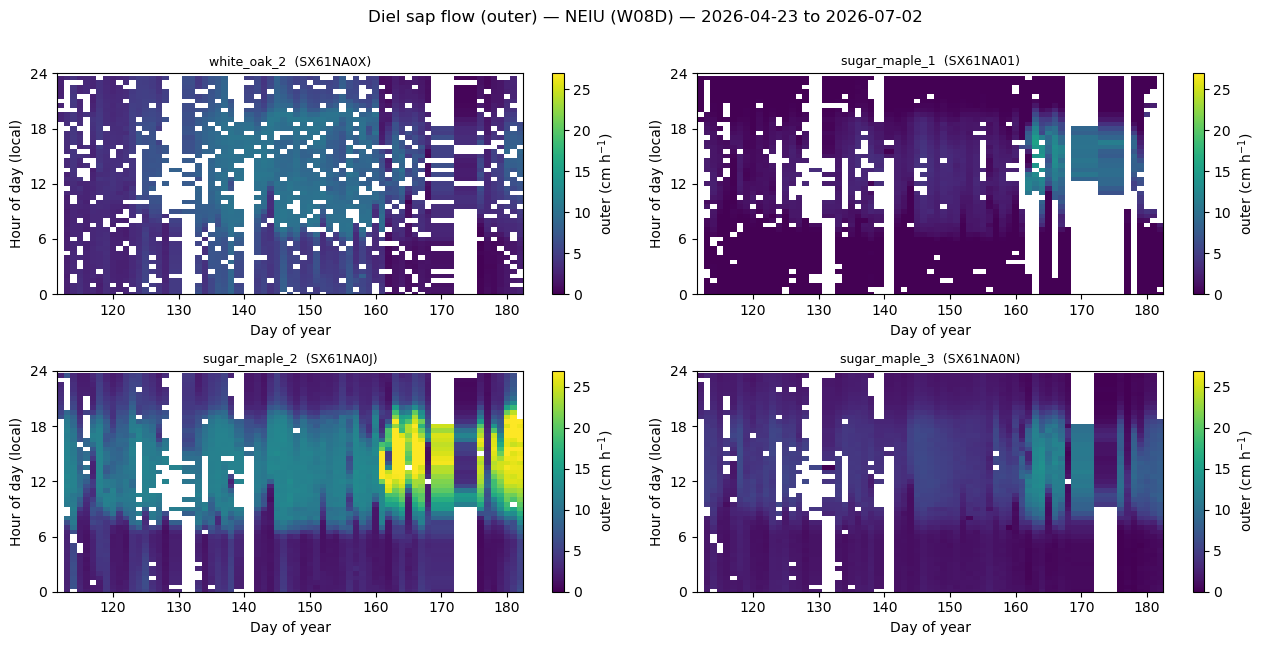

In [9]:
GRID_MIN = 30          # fixed grid for the heatmap, in minutes
DEPTH    = "outer"     # which thermistor to map: "outer" or "inner"
LOCAL_TZ = "US/Central"

def diel_frame(df, value=DEPTH, grid_min=GRID_MIN, tz=LOCAL_TZ):
    """Resample to a fixed grid, convert to local time, return a
    (hour-of-day  x  day-of-year) pivot table of `value`."""
    s = df[value].copy()
    # Ensure a UTC tz-aware index, then convert to local
    if s.index.tz is None:
        s.index = s.index.tz_localize("UTC")
    s = s.tz_convert(tz)
    s = s.resample(f"{grid_min}min").mean()

    out = pd.DataFrame({value: s})
    out["hod"] = out.index.hour + out.index.minute / 60.0
    out["doy"] = out.index.dayofyear
    mesh = out.pivot_table(index="hod", columns="doy", values=value)
    return mesh


if sapflow:
    n = len(sapflow)
    ncols = 2
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.2 * nrows),
                             squeeze=False)

    # Shared color scale across trees for comparability
    vmax = max((df[DEPTH].quantile(0.98) for df in sapflow.values()
                if df[DEPTH].notna().any()), default=None)

    for ax, (species, df) in zip(axes.flat, sapflow.items()):
        serial = df["serial"].iloc[0] if "serial" in df.columns else "?"
        mesh = diel_frame(df)
        if mesh.empty or mesh.isna().all().all():
            ax.set_title(f"{species} — no data")
            ax.axis("off")
            continue
        X = mesh.columns.values          # day of year
        Y = mesh.index.values            # hour of day
        Z = mesh.values
        pcm = ax.pcolormesh(X, Y, Z, shading="auto", cmap="viridis",
                            vmin=0, vmax=vmax)
        ax.set_title(f"{species}  ({serial})", fontsize=9)
        ax.set_xlabel("Day of year")
        ax.set_ylabel("Hour of day (local)")
        ax.set_ylim(0, 24)
        ax.set_yticks([0, 6, 12, 18, 24])
        fig.colorbar(pcm, ax=ax, label=f"{DEPTH} (cm h$^{{-1}}$)")

    # Hide any unused panels
    for ax in axes.flat[n:]:
        ax.axis("off")

    fig.suptitle(f"Diel sap flow ({DEPTH}) — {SITE.abbr} ({SITE.vsn}) — "
                 f"{START} to {END}", fontsize=12, y=1.0)
    fig.tight_layout()
    plt.savefig(f"figures/{SITE.abbr}_sapflow_diel.png",
                dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No sap flow data to map.")

## Quick QC: reporting and battery

A short reporting/battery summary — sap flow meters that drop out are usually
power-starved, so battery voltage is the first thing to check when a tree goes
quiet.


In [10]:
if sapflow:
    for serial, df in sapflow.items():
        species = SITE.sapflow.get(serial, serial)
        bmin = df["battery_voltage"].min() if "battery_voltage" in df else float("nan")
        bmax = df["battery_voltage"].max() if "battery_voltage" in df else float("nan")
        print(f"{species:<16} {serial}: {len(df):5d} rows, "
              f"{df['outer'].isna().sum():4d} NaN outer, "
              f"battery {bmin:.2f}–{bmax:.2f} V")

white_oak_2      white_oak_2:  3428 rows,    6 NaN outer, battery 4.00–4.19 V
sugar_maple_1    sugar_maple_1:  3527 rows,    6 NaN outer, battery 3.65–4.19 V
sugar_maple_2    sugar_maple_2:  5222 rows,    4 NaN outer, battery 3.69–4.19 V
sugar_maple_3    sugar_maple_3:  5220 rows,    5 NaN outer, battery 3.88–4.21 V


## Stub: conversion to volumetric sap flow (kg h⁻¹)

**Not active** — this needs per-tree measurements we do not have yet
(circumference → DBH → sapwood area, plus wood density and water content). When
those arrive, this converts uncorrected heat-pulse velocity to volumetric flow via
the wound correction and Marshall (1958) equation. Left here as scaffolding.


In [11]:
def compute_sap_flow(V_h, sapwood_area_cm2,
                     rho_b=0.55, water_content=1.0,
                     b=1.7304, c=-0.0013, d=0.0002):
    """Convert uncorrected heat-pulse velocity (cm/hr) to sap flow (kg/hr).

    PLACEHOLDER constants — replace rho_b, water_content, sapwood_area_cm2,
    and the wound coefficients (b, c, d) with per-tree measured values once
    circumference / core data are available.

    Parameters
    ----------
    V_h : array-like
        Uncorrected heat-pulse velocity (cm/hr), e.g. df['outer'].
    sapwood_area_cm2 : float
        Sapwood cross-sectional area (cm^2), from core + DBH.
    rho_b : float
        Basic wood density (dry weight / green volume).
    water_content : float
        Sapwood water content m_c (mass water / mass dry wood).
    b, c, d : float
        Wound-correction coefficients (SFM1 manual, for the wound diameter).
    """
    C_W = 1200.0   # J/kg/°C, wood matrix
    C_S = 4182.0   # J/kg/°C, sap (water)
    RHO_S = 1.0    # density of water

    V_h = np.asarray(V_h, dtype=float)
    V_c = b * V_h + c * V_h**2 + d * V_h**3              # wound correction
    V_s = V_c * rho_b * (C_W + water_content * C_S) / (RHO_S * C_S)  # cm/hr
    flux_kg_hr = V_s * sapwood_area_cm2 / 1000.0
    return flux_kg_hr

# Example (inactive until sapwood_area is known):
# flux = compute_sap_flow(sapflow["SX61NA0C"]["outer"], sapwood_area_cm2=180.0)

## Appendix & references

**Full heat-transport derivation (summary).** Conduction of heat in an isotropic
medium with thermal diffusivity $\alpha$ obeys
$\partial T/\partial t = \alpha\nabla^2 T$. Adding advection by sap moving at speed
$w$ introduces a term $-w\,\partial T/\partial z$. The Heat Ratio Method solves the
resulting balance from the ratio of temperature rises at two symmetric thermistors,
which yields the $V_h$ expression above. See Burgess et al. (2001) for the complete
treatment, including reverse and low-flow behavior, and the SFM1 manual for the
implementation and wound-correction coefficients.

**References**

- Burgess, S. S. O., et al. (2001). An improved heat pulse method to measure low
  and reverse rates of sap flow in woody plants. *Tree Physiology* 21, 589–598.
- Marshall, D. C. (1958). Measurement of sap flow in conifers by heat transport.
  *Plant Physiology* 33, 385–396.
- Swanson, R. H., & Whitfield, D. W. A. (1981). A numerical analysis of heat pulse
  velocity theory and practice. *J. Exp. Bot.* 32, 221–239.
- ICT International, SFM1 Sap Flow Meter Manual (v5).
- Buck, A. L. (1981, 1996). New equations for computing vapor pressure and
  enhancement factor. *J. Appl. Meteorol.*
